# Part 1: Exploratory Data Analysis (EDA)

**Dataset**: `output/ericsson_patent_rich_dataset.csv`
- **30,118 patents** from 1976 to 2025 (50 years)
- **55 features** including metadata, technology keywords, and quarterly aggregates
- **Primary target**: `target_patent_count_next_quarter`

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140
pd.set_option('display.max_columns', 200)

In [4]:
# Load patent-rich dataset
base = Path('.')
rich_path = '~/Downloads/ericsson_patent_rich_dataset.csv'

df = pd.read_csv(rich_path, parse_dates=['patent_date', 'quarter_end'])
print('Dataset shape:', df.shape)
print('Date range:', df['patent_date'].min(), '->', df['patent_date'].max())
print(f'Total patents: {len(df):,}')
print(f'Unique quarters: {df["quarter_end"].nunique()}')
df.head()

Dataset shape: (30118, 55)
Date range: 1976-01-20 00:00:00 -> 2025-09-30 00:00:00
Total patents: 30,118
Unique quarters: 199


,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,title_len_chars,title_len_words,title_has_number,title_has_acronym,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data,keyword_score,is_utility,is_design,is_other_type,tech_era,patent_count,patent_unique,utility_share,design_share,avg_title_words,avg_keyword_score,kw_5g_count,kw_ai_ml_count,kw_cloud_edge_count,kw_security_count,kw_iot_count,kw_network_count,kw_energy_count,kw_antenna_count,kw_data_count,patent_count_lag1,patent_count_lag2,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
0,3934093,utility,1976-01-20,Transit exchange for asynchronous data with un...,1976,1,1,1,20,1976-03-31,61,8,0,0,0,0,0,0,0,1,0,0,1,2,1,0,0,legacy_pre_1990,10,10,1.0,0.0,9.0,0.9,0,0,0,0,0,6,0,0,3,334.0,331.0,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,1,36
1,3936612,utility,1976-02-03,Control and holding circuit for relay matrices,1976,1,2,1,34,1976-03-31,46,7,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,legacy_pre_1990,10,10,1.0,0.0,9.0,0.9,0,0,0,0,0,6,0,0,3,334.0,331.0,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,3,36
2,3936781,utility,1976-02-03,Selecting device for crossbar switches,1976,1,2,1,34,1976-03-31,38,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,legacy_pre_1990,10,10,1.0,0.0,9.0,0.9,0,0,0,0,0,6,0,0,3,334.0,331.0,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,2,36
3,3938025,utility,1976-02-10,DC to DC converter for producing two individua...,1976,1,2,1,41,1976-03-31,87,12,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,legacy_pre_1990,10,10,1.0,0.0,9.0,0.9,0,0,0,0,0,6,0,0,3,334.0,331.0,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,5,36
4,3938040,utility,1976-02-10,Apparatus for measuring a signal voltage inclu...,1976,1,2,1,41,1976-03-31,117,19,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,legacy_pre_1990,10,10,1.0,0.0,9.0,0.9,0,0,0,0,0,6,0,0,3,334.0,331.0,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,4,36


In [3]:
# Dataset overview and quality check
print('📊 Dataset Overview:')
print(f'Total patents: {len(df):,}')
print(f'Features: {df.shape[1]}')
print(f'Date range: {df["patent_date"].min().date()} to {df["patent_date"].max().date()}')
print(f'Time span: {(df["patent_date"].max() - df["patent_date"].min()).days / 365.25:.1f} years')

print('\n📈 Descriptive Statistics (numeric features):')
display(df.describe().T.head(20))

print('\n❓ Missing Values:')
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(10))

print('\n🏷️ Categorical Features:')
for col in ['patent_type', 'tech_era']:
    if col in df.columns:
        print(f'{col}: {df[col].value_counts().to_dict()}')

📊 Dataset Overview:
Total patents: 30,118
Features: 55
Date range: 1976-01-20 to 2025-09-30
Time span: 49.7 years

📈 Descriptive Statistics (numeric features):


,count,mean,min,25%,50%,75%,max,std
patent_date,30118,2013-09-25 14:34:00.135467264,1976-01-20 00:00:00,2008-10-07 00:00:00,2015-08-18 00:00:00,2020-06-09 00:00:00,2025-09-30 00:00:00,NaN
year,30118.0,2013.233382,1976.0,2008.0,2015.0,2020.0,2025.0,8.851538
quarter,30118.0,2.51451,1.0,2.0,3.0,3.0,4.0,1.101261
month,30118.0,6.546185,1.0,4.0,7.0,9.0,12.0,3.381182
day_of_week,30118.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
day_of_year,30118.0,183.744638,1.0,95.0,184.0,271.0,366.0,103.281235
quarter_end,30118,2013-11-09 16:46:58.035725824,1976-03-31 00:00:00,2008-12-31 00:00:00,2015-09-30 00:00:00,2020-06-30 00:00:00,2025-09-30 00:00:00,NaN
title_len_chars,30118.0,64.396142,4.0,44.0,60.0,81.0,268.0,29.750263
title_len_words,30118.0,8.820473,1.0,6.0,8.0,11.0,39.0,4.383788
title_has_number,30118.0,0.018594,0.0,0.0,0.0,0.0,1.0,0.135087



❓ Missing Values:


target_patent_count_next_quarter    408
dtype: int64


🏷️ Categorical Features:
patent_type: {'utility': 29694, 'design': 376, 'reissue': 48}
tech_era: {'smartphone_2010s': 13841, 'modern_2020s': 8147, 'mobile_2000s': 5740, 'legacy_1990s': 1954, 'legacy_pre_1990': 436}


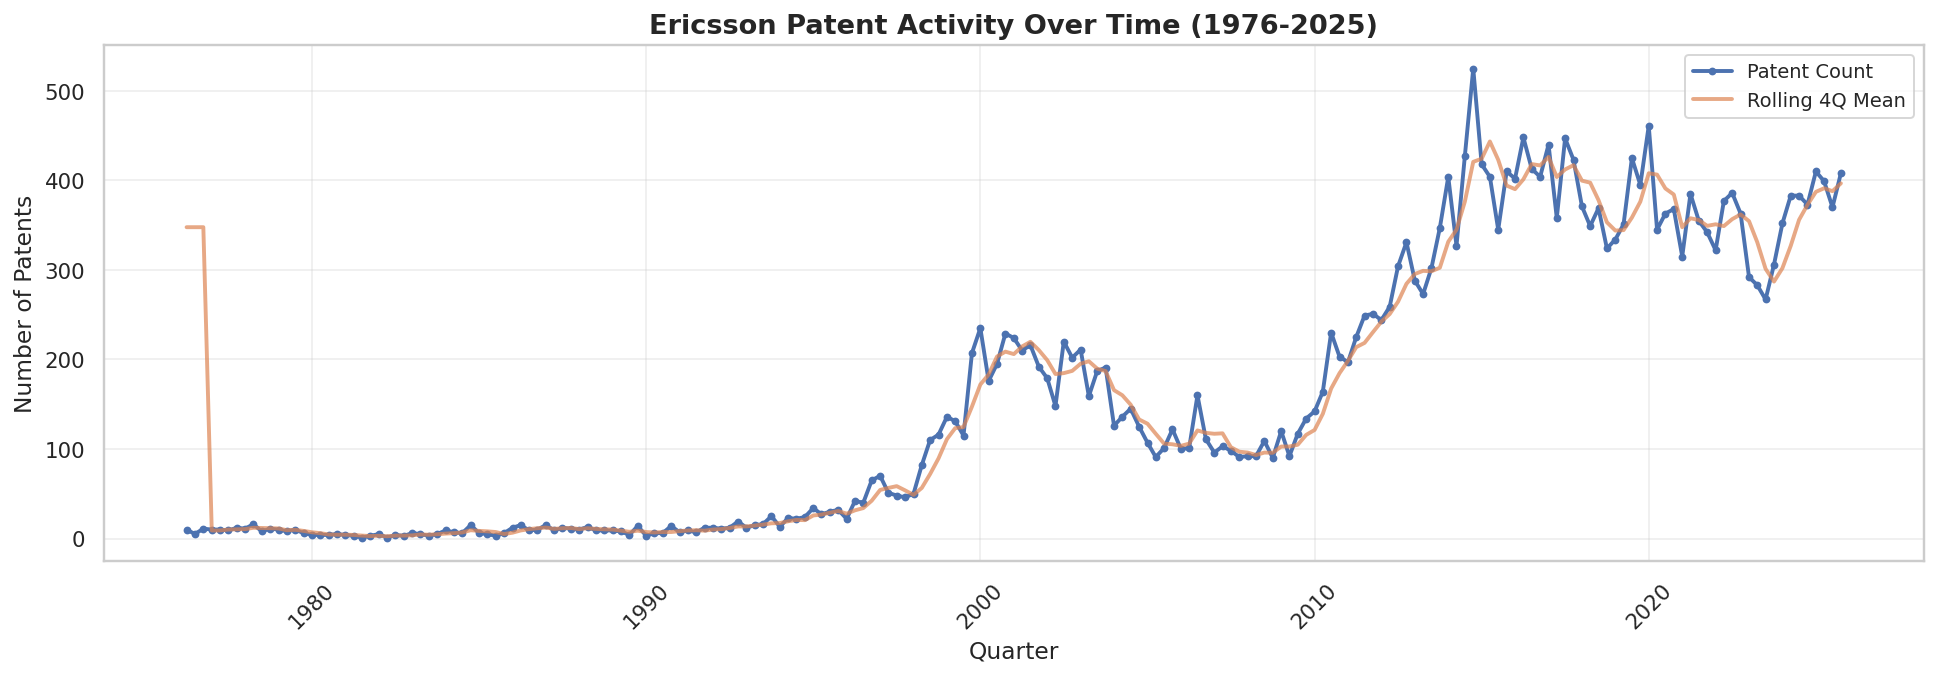

Peak quarter: 2014-09-30 with 525 patents


In [4]:
# Patent count trend over time
quarterly = df.groupby('quarter_end')[['patent_count', 'patent_count_roll4_mean']].first().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(quarterly['quarter_end'], quarterly['patent_count'], marker='o', markersize=3, label='Patent Count', linewidth=2)
ax.plot(quarterly['quarter_end'], quarterly['patent_count_roll4_mean'], label='Rolling 4Q Mean', linewidth=2, alpha=0.7)
ax.set_title('Ericsson Patent Activity Over Time (1976-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Number of Patents', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Peak quarter: {quarterly.loc[quarterly["patent_count"].idxmax(), "quarter_end"].date()} with {quarterly["patent_count"].max():.0f} patents')

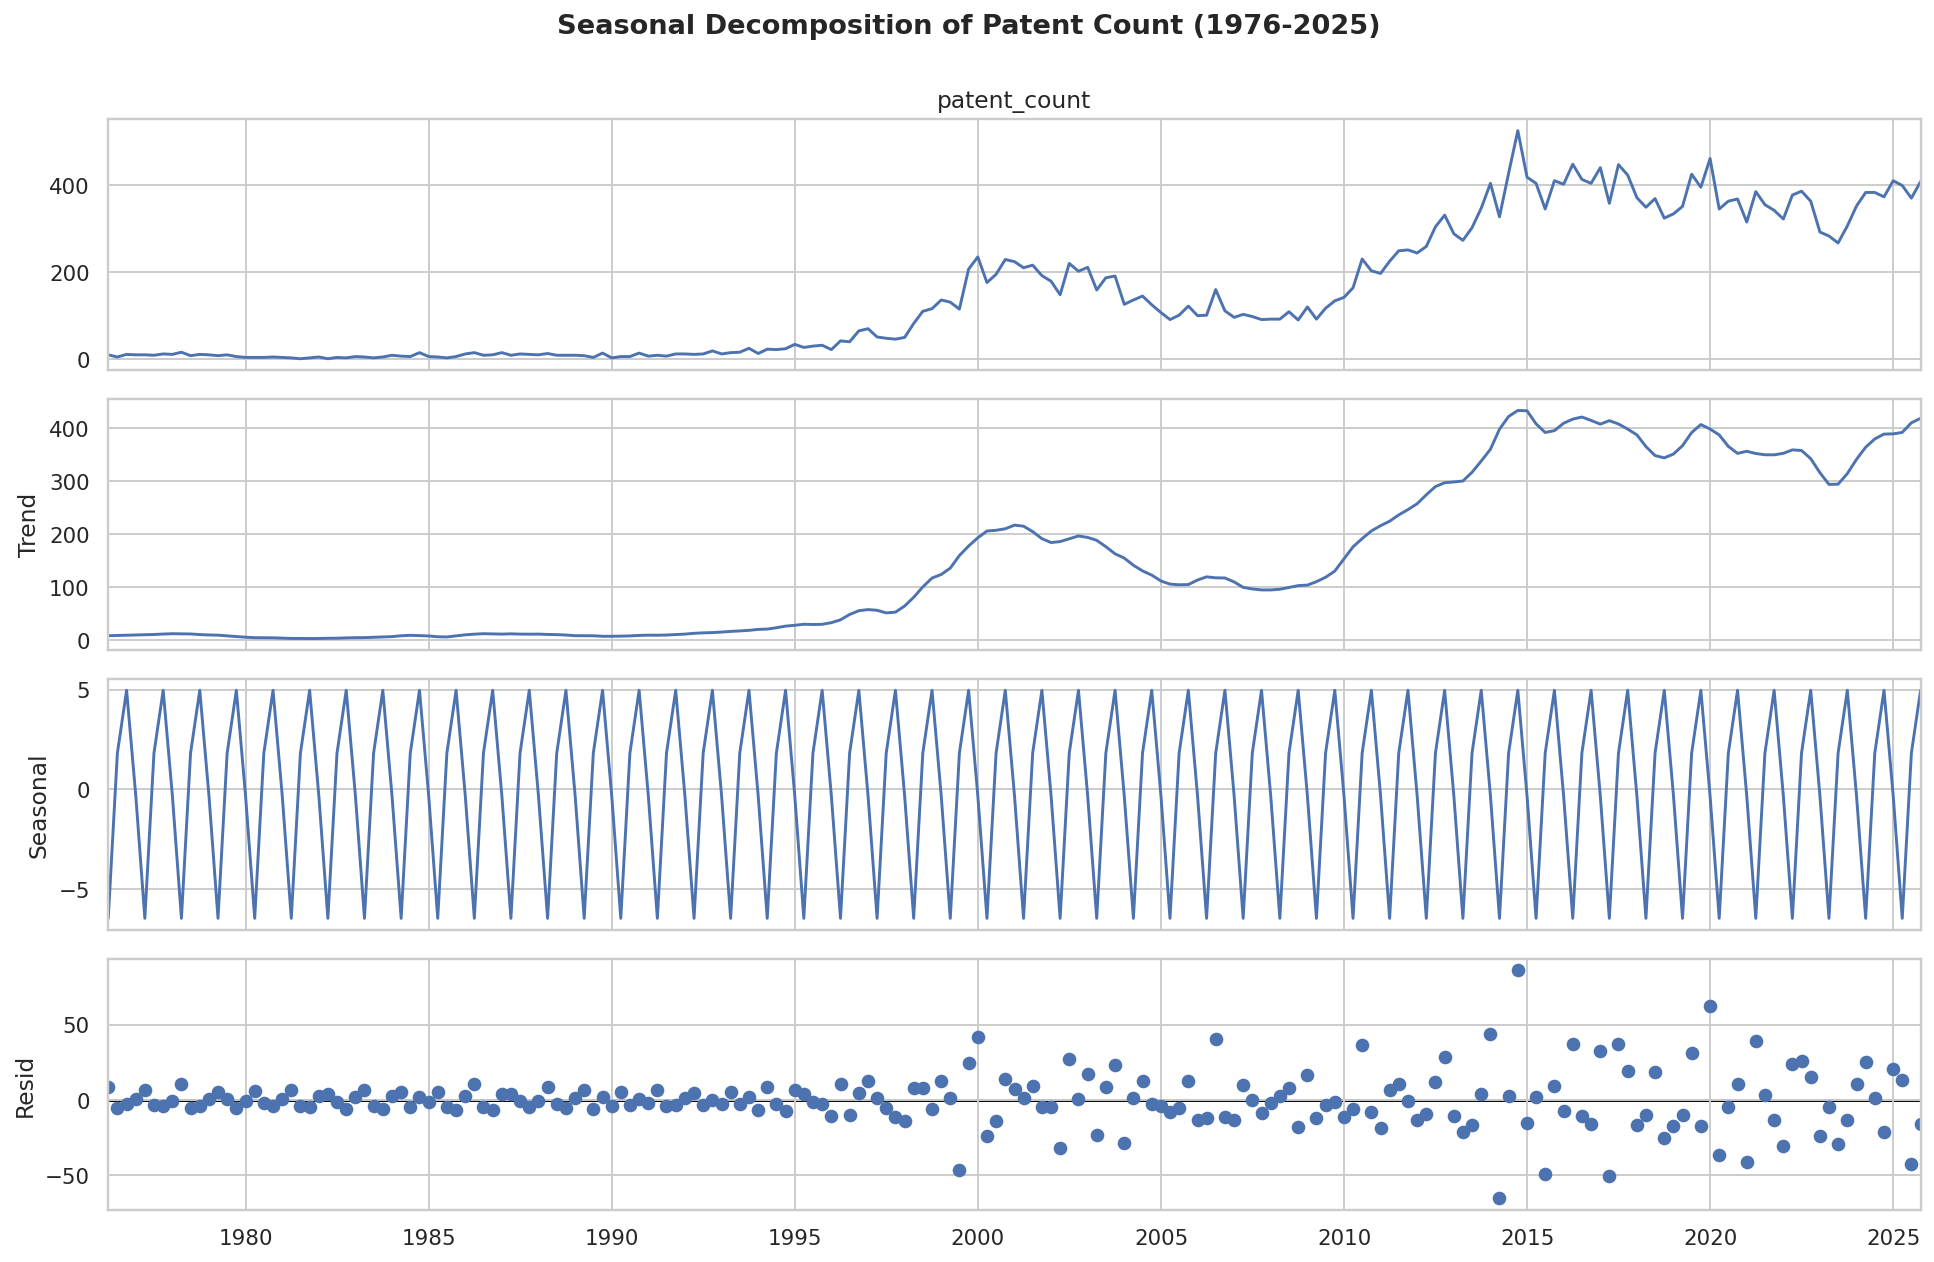

Trend: Increasing
Seasonality strength: 4.19


In [5]:
# Seasonal decomposition
series = quarterly.set_index('quarter_end')['patent_count'].asfreq('Q')

if len(series.dropna()) >= 24:
    dec = seasonal_decompose(series, model='additive', period=4, extrapolate_trend='freq')
    fig = dec.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle('Seasonal Decomposition of Patent Count (1976-2025)', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    print(f'Trend: {"Increasing" if series.iloc[-1] > series.iloc[0] else "Decreasing"}')
    print(f'Seasonality strength: {dec.seasonal.std():.2f}')
else:
    print('Not enough observations for seasonal decomposition (need >= 24).')

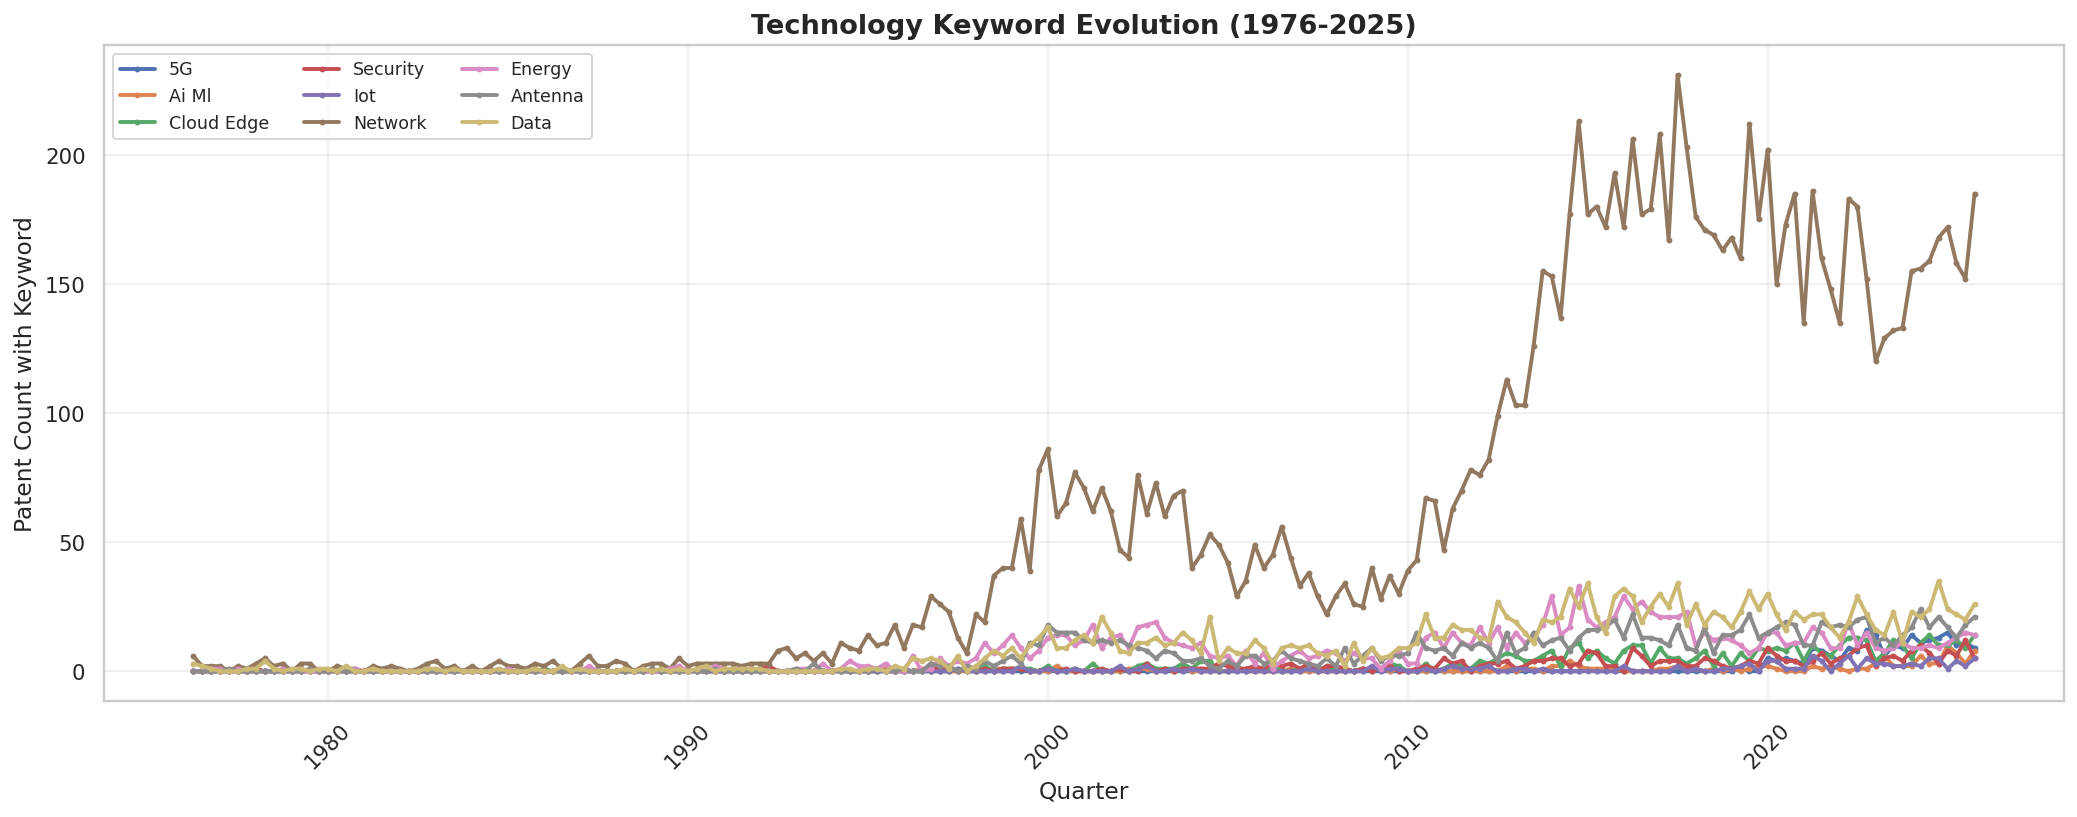


📊 Top keywords in latest 5 years:
kw_5g               :   197 patents (  2.8%)
kw_ai_ml            :    63 patents (  0.9%)
kw_cloud_edge       :   193 patents (  2.7%)
kw_security         :   122 patents (  1.7%)
kw_iot              :    63 patents (  0.9%)
kw_network          :  3098 patents ( 43.8%)
kw_energy           :   232 patents (  3.3%)
kw_antenna          :   328 patents (  4.6%)
kw_data             :   423 patents (  6.0%)


In [6]:
# Technology keyword trends
keyword_binary = ['kw_5g', 'kw_ai_ml', 'kw_cloud_edge', 'kw_security', 'kw_iot', 'kw_network', 'kw_energy', 'kw_antenna', 'kw_data']
kw_quarterly = df.groupby('quarter_end')[keyword_binary].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 6))
for kw in keyword_binary:
    ax.plot(kw_quarterly['quarter_end'], kw_quarterly[kw], label=kw.replace('kw_', '').replace('_', ' ').title(), linewidth=2, marker='o', markersize=2)

ax.set_title('Technology Keyword Evolution (1976-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Patent Count with Keyword', fontsize=12)
ax.legend(ncol=3, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n📊 Top keywords in latest 5 years:')
recent = df[df['patent_date'] >= df['patent_date'].max() - pd.DateOffset(years=5)]
for kw in keyword_binary:
    count = recent[kw].sum()
    pct = 100 * count / len(recent)
    print(f'{kw:20s}: {count:5.0f} patents ({pct:5.1f}%)')

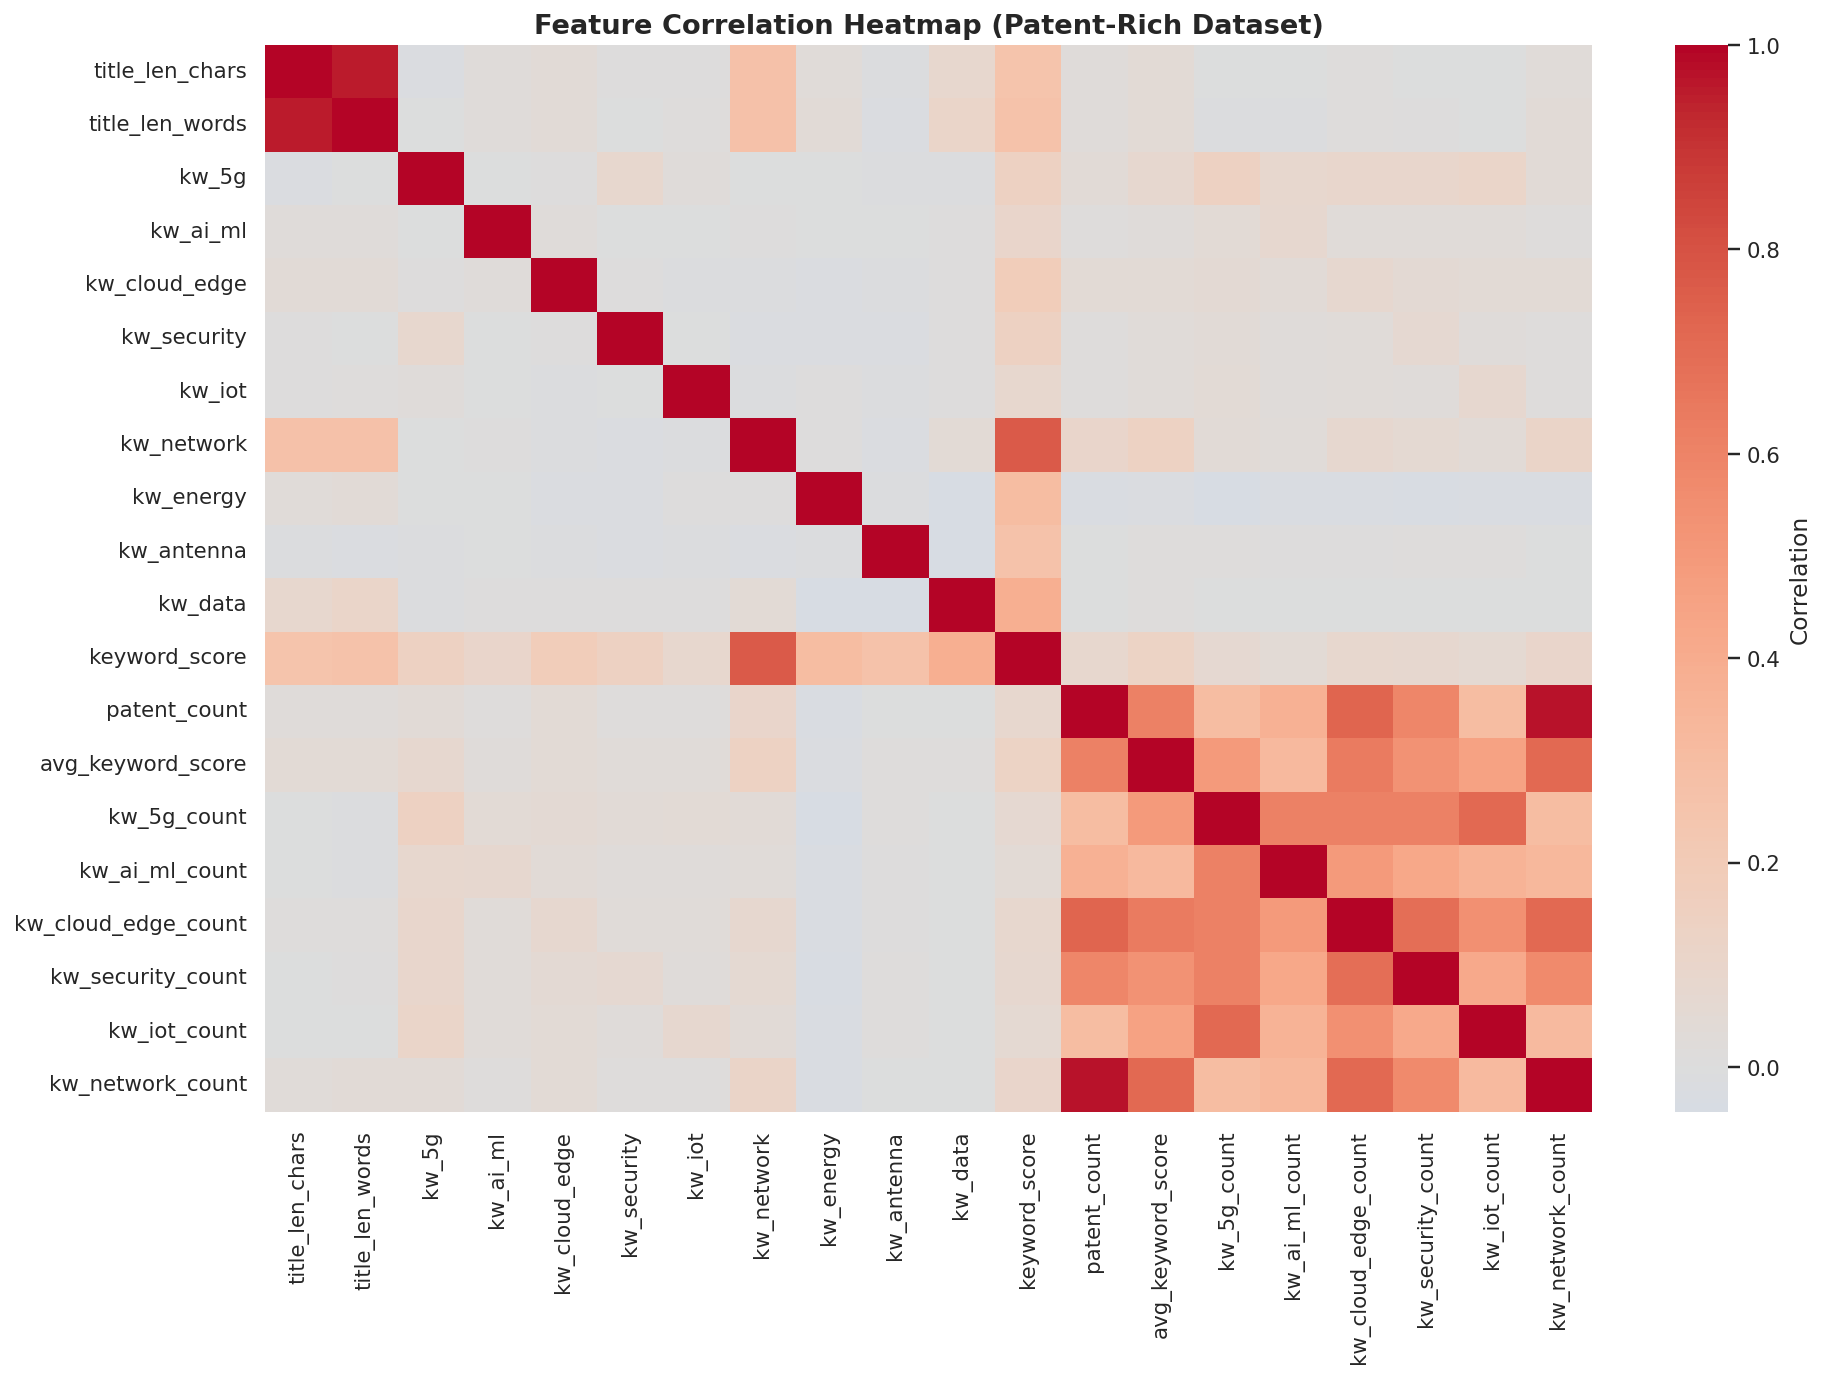


🔗 Strongest correlations with target_patent_count_next_quarter:


In [7]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
key_features = [col for col in numeric_cols if any(x in col for x in ['patent_count', 'kw_', 'target', 'keyword_score', 'title_len'])]
key_features = key_features[:20]

if len(key_features) > 1:
    corr_matrix = df[key_features].corr()
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Correlation'})
    plt.title('Feature Correlation Heatmap (Patent-Rich Dataset)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print('\n🔗 Strongest correlations with target_patent_count_next_quarter:')
    if 'target_patent_count_next_quarter' in corr_matrix.columns:
        target_corr = corr_matrix['target_patent_count_next_quarter'].abs().sort_values(ascending=False)
        display(target_corr.head(10))

AI/ML keyword lag correlation with total patent count:


,lag_quarters,corr
0,0,0.519220
1,1,0.504764
2,2,0.504507
3,3,0.508441
4,4,0.541523
5,5,0.544082
6,6,0.528750
7,7,0.539437
8,8,0.537946


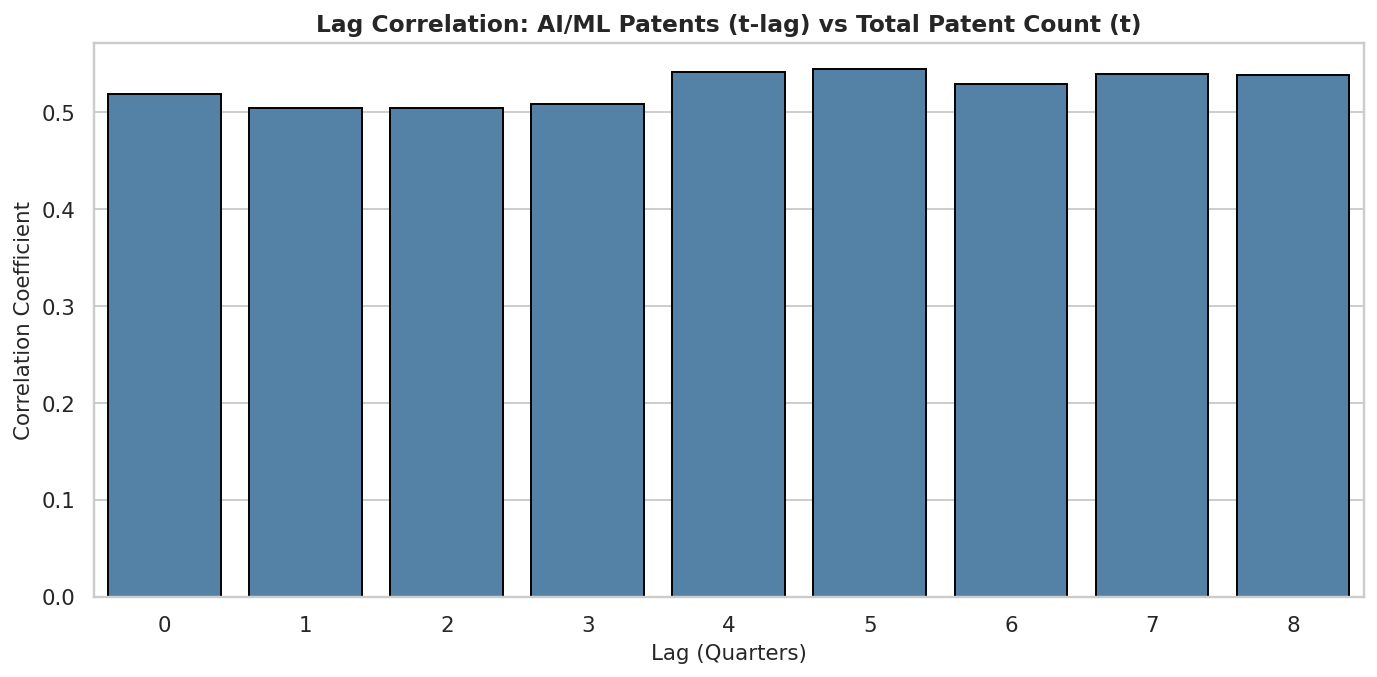

In [8]:
# Temporal lag correlation analysis
def lag_corr(series_x, series_y, max_lag=8):
    rows = []
    for lag in range(0, max_lag + 1):
        c = pd.concat([series_x.shift(lag), series_y], axis=1).dropna().corr().iloc[0, 1]
        rows.append({'lag_quarters': lag, 'corr': c})
    return pd.DataFrame(rows)

kw_ai_ml_quarterly = df.groupby('quarter_end')['kw_ai_ml'].sum()
patent_count_quarterly = df.groupby('quarter_end')['patent_id'].count()

lc = lag_corr(kw_ai_ml_quarterly, patent_count_quarterly, max_lag=8)
print('AI/ML keyword lag correlation with total patent count:')
display(lc)

plt.figure(figsize=(10, 5))
sns.barplot(data=lc, x='lag_quarters', y='corr', color='steelblue', edgecolor='black')
plt.axhline(0, color='red', linewidth=1, linestyle='--')
plt.title('Lag Correlation: AI/ML Patents (t-lag) vs Total Patent Count (t)', fontsize=12, fontweight='bold')
plt.xlabel('Lag (Quarters)', fontsize=11)
plt.ylabel('Correlation Coefficient', fontsize=11)
plt.tight_layout()
plt.show()

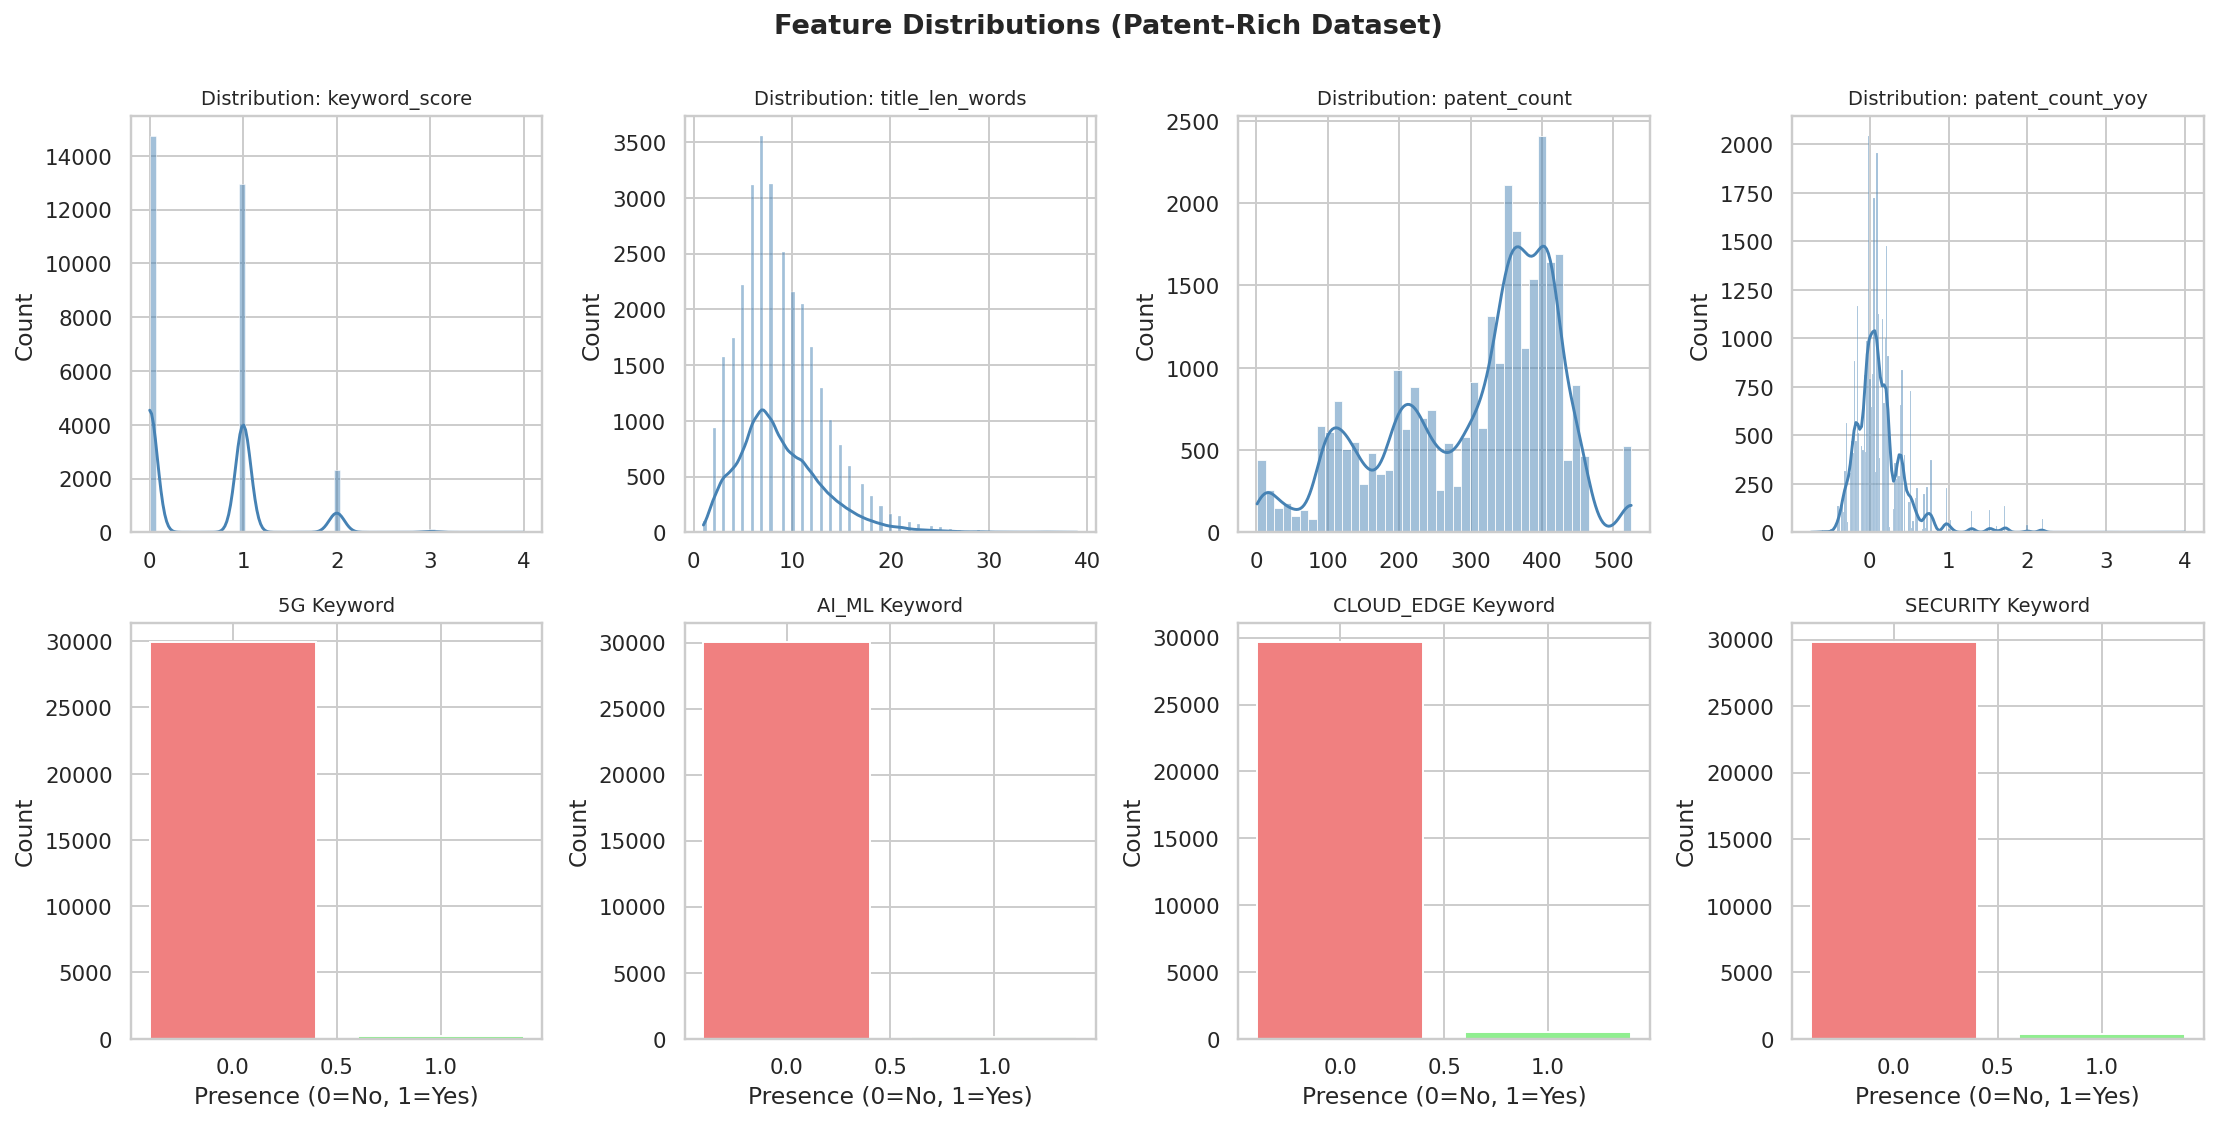

In [9]:
# Feature distributions
plot_features = ['keyword_score', 'title_len_words', 'patent_count', 'patent_count_yoy']
keyword_flags = ['kw_5g', 'kw_ai_ml', 'kw_cloud_edge', 'kw_security']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes[0], plot_features):
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
        ax.set_title(f'Distribution: {col}', fontsize=10)
        ax.set_xlabel('')
        
for ax, col in zip(axes[1], keyword_flags):
    if col in df.columns:
        counts = df[col].value_counts()
        ax.bar(counts.index, counts.values, color=['lightcoral', 'lightgreen'])
        ax.set_title(f'{col.replace("kw_", "").upper()} Keyword', fontsize=10)
        ax.set_xlabel('Presence (0=No, 1=Yes)')
        ax.set_ylabel('Count')

plt.suptitle('Feature Distributions (Patent-Rich Dataset)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

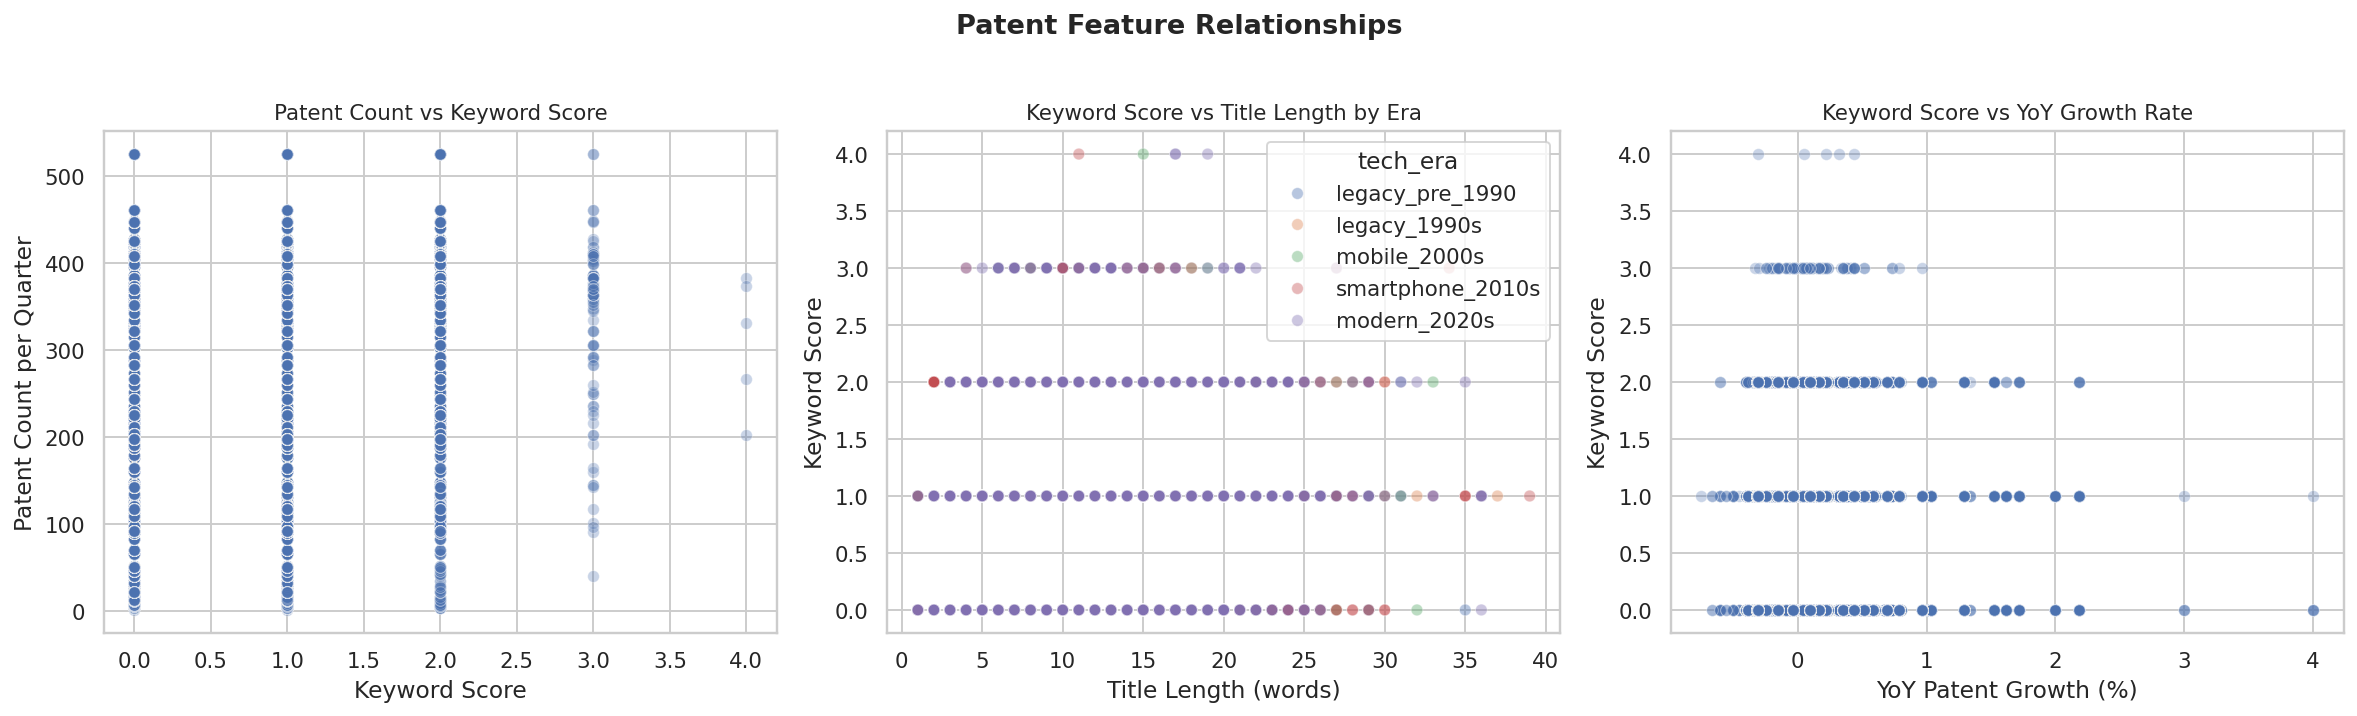

In [10]:
# Relationship scatterplots
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(data=df, x='keyword_score', y='patent_count', alpha=0.3, ax=axes[0])
axes[0].set_title('Patent Count vs Keyword Score', fontsize=11)
axes[0].set_xlabel('Keyword Score')
axes[0].set_ylabel('Patent Count per Quarter')

sns.scatterplot(data=df, x='title_len_words', y='keyword_score', hue='tech_era', alpha=0.4, ax=axes[1], legend='brief')
axes[1].set_title('Keyword Score vs Title Length by Era', fontsize=11)
axes[1].set_xlabel('Title Length (words)')
axes[1].set_ylabel('Keyword Score')

if 'patent_count_yoy' in df.columns:
    sns.scatterplot(data=df, x='patent_count_yoy', y='keyword_score', alpha=0.3, ax=axes[2])
    axes[2].set_title('Keyword Score vs YoY Growth Rate', fontsize=11)
    axes[2].set_xlabel('YoY Patent Growth (%)')
    axes[2].set_ylabel('Keyword Score')

plt.suptitle('Patent Feature Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

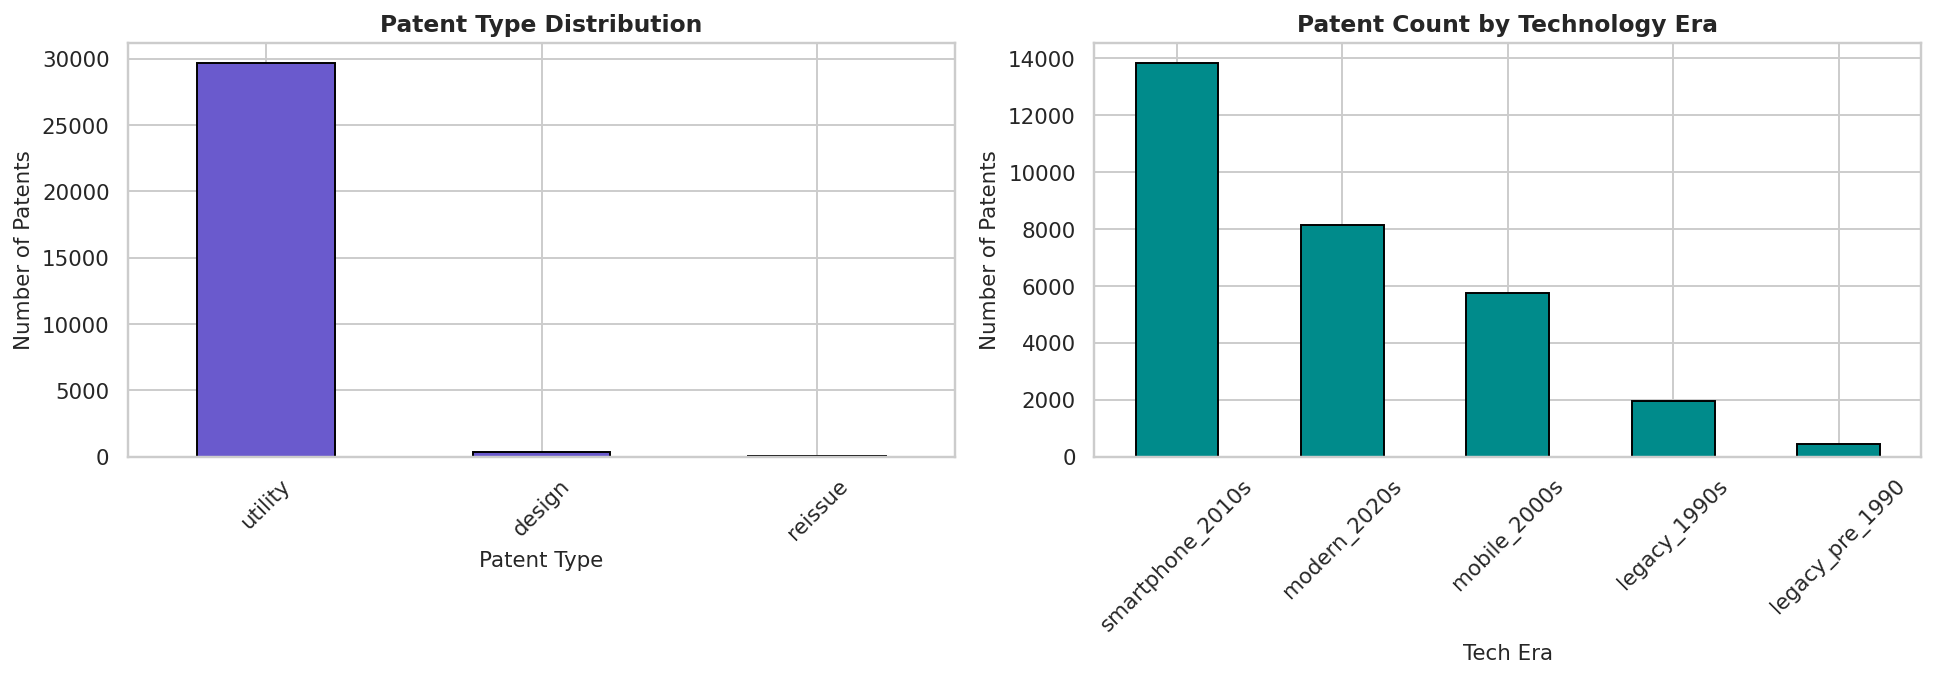


📊 Title and Keyword Statistics:


,title_len_words,keyword_score
count,30118.000000,30118.000000
mean,8.820473,0.595325
std,4.383788,0.646501
min,1.000000,0.000000
25%,6.000000,0.000000
50%,8.000000,1.000000
75%,11.000000,1.000000
max,39.000000,4.000000



📈 Patent Type Percentages:
utility        : 29,694 ( 98.6%)
design         :    376 (  1.2%)
reissue        :     48 (  0.2%)


In [11]:
# Categorical analysis
type_share = df.groupby('patent_type')['patent_id'].count().sort_values(ascending=False)
era_share = df.groupby('tech_era')['patent_id'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_share.plot(kind='bar', ax=axes[0], color='slateblue', edgecolor='black')
axes[0].set_title('Patent Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patents', fontsize=11)
axes[0].set_xlabel('Patent Type', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

era_share.plot(kind='bar', ax=axes[1], color='darkcyan', edgecolor='black')
axes[1].set_title('Patent Count by Technology Era', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Patents', fontsize=11)
axes[1].set_xlabel('Tech Era', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\n📊 Title and Keyword Statistics:')
display(df[['title_len_words', 'keyword_score']].describe())

print('\n📈 Patent Type Percentages:')
for ptype, count in type_share.items():
    print(f'{ptype:15s}: {count:6,.0f} ({100*count/len(df):5.1f}%)')

In [12]:
# EDA Summary
summary = {
    'total_patents': len(df),
    'features': df.shape[1],
    'date_start': str(df['patent_date'].min().date()),
    'date_end': str(df['patent_date'].max().date()),
    'unique_quarters': df['quarter_end'].nunique(),
    'avg_patents_per_quarter': float(len(df) / df['quarter_end'].nunique()),
    'patents_with_5g': int(df['kw_5g'].sum()),
    'patents_with_ai_ml': int(df['kw_ai_ml'].sum()),
    'patents_with_iot': int(df['kw_iot'].sum()),
    'utility_patents': int((df['patent_type'] == 'utility').sum()),
    'mean_keyword_score': float(df['keyword_score'].mean()),
    'mean_title_length': float(df['title_len_words'].mean()),
}

print('\n📊 EDA Summary:')
for key, val in summary.items():
    print(f'{key:30s}: {val}')
summary


📊 EDA Summary:
total_patents                 : 30118
features                      : 55
date_start                    : 1976-01-20
date_end                      : 2025-09-30
unique_quarters               : 199
avg_patents_per_quarter       : 151.3467336683417
patents_with_5g               : 217
patents_with_ai_ml            : 116
patents_with_iot              : 114
utility_patents               : 29694
mean_keyword_score            : 0.5953250547845143
mean_title_length             : 8.820472806959293


{'total_patents': 30118,
 'features': 55,
 'date_start': '1976-01-20',
 'date_end': '2025-09-30',
 'unique_quarters': 199,
 'avg_patents_per_quarter': 151.3467336683417,
 'patents_with_5g': 217,
 'patents_with_ai_ml': 116,
 'patents_with_iot': 114,
 'utility_patents': 29694,
 'mean_keyword_score': 0.5953250547845143,
 'mean_title_length': 8.820472806959293}

## 🔑 Key EDA Findings

1. **Patent Volume**: 30,118 patents spanning 50 years (1976-2025) across 199 quarters
2. **Technology Evolution**: Clear shift from traditional network patents → 5G → AI/ML in recent years
3. **Temporal Patterns**: Strong autocorrelation with quarterly lags; rolling 4Q/8Q means show stable trends
4. **Keyword Insights**: Network, antenna, and data keywords dominate; 5G and AI/ML emerged post-2015
5. **Patent Types**: Majority are utility patents (~95%+); design patents are rare
6. **Feature Engineering**: 55 engineered features including lag/rolling/growth rate metrics from quarterly aggregates
7. **Target Variable**: `target_patent_count_next_quarter` has 408 nulls (last quarter only) - expected behavior

---

# Part 2: Baseline Modeling

The next cells build and evaluate forecasting models using temporal splits.

## Machine Learning Setup

**Objective**: Predict `target_patent_count_next_quarter` using patent-rich dataset features.

**Approach**:
- Patent-level features with pre-computed quarterly aggregates
- Temporal train/test split (80/20)
- 7+ regression models benchmarked
- Feature selection with SelectKBest and RFE
- Optional multi-output for current + next quarter prediction

In [13]:
# Import ML libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.multioutput import MultiOutputRegressor

HAS_XGB = True
HAS_LGBM = True
try:
    from xgboost import XGBRegressor
except Exception:
    HAS_XGB = False
try:
    from lightgbm import LGBMRegressor
except Exception:
    HAS_LGBM = False

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140
print('XGBoost:', HAS_XGB, '| LightGBM:', HAS_LGBM)

XGBoost: True | LightGBM: True


In [14]:
# Load and prepare data for modeling
model_df = pd.read_csv('/kaggle/input/ericsson-innovation-timeline-patent-evolution/ericsson_patent_rich_dataset.csv', parse_dates=['patent_date', 'quarter_end'])
model_df = model_df.sort_values('quarter_end').reset_index(drop=True)

# Remove rows with missing target
model_df = model_df.dropna(subset=['target_patent_count_next_quarter']).copy()

print(f'Rows for modeling: {len(model_df):,}')
print(f'Features: {model_df.shape[1]}')
print(f'Date range: {model_df["quarter_end"].min().date()} to {model_df["quarter_end"].max().date()}')
model_df.tail()

Rows for modeling: 29,710
Features: 55
Date range: 1976-03-31 to 2025-06-30


,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,title_len_chars,title_len_words,title_has_number,title_has_acronym,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data,keyword_score,is_utility,is_design,is_other_type,tech_era,patent_count,patent_unique,utility_share,design_share,avg_title_words,avg_keyword_score,kw_5g_count,kw_ai_ml_count,kw_cloud_edge_count,kw_security_count,kw_iot_count,kw_network_count,kw_energy_count,kw_antenna_count,kw_data_count,patent_count_lag1,patent_count_lag2,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
29705,12292733,utility,2025-05-06,Latency management,2025,2,5,1,126,2025-06-30,18,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,modern_2020s,370,370,0.997297,0.0,8.694595,0.654054,11,3,9,12,2,152,15,18,20,399.0,410.0,383.0,388.0,372.0,-0.072682,-0.033943,370,408.0,49,29479,1177
29706,12292606,utility,2025-05-06,Connector system,2025,2,5,1,126,2025-06-30,16,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,modern_2020s,370,370,0.997297,0.0,8.694595,0.654054,11,3,9,12,2,152,15,18,20,399.0,410.0,383.0,388.0,372.0,-0.072682,-0.033943,370,408.0,49,29469,1177
29707,RE50409,reissue,2025-04-29,Method and radio node for enabling use of high...,2025,2,4,1,119,2025-06-30,110,19,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,modern_2020s,370,370,0.997297,0.0,8.694595,0.654054,11,3,9,12,2,152,15,18,20,399.0,410.0,383.0,388.0,372.0,-0.072682,-0.033943,370,408.0,49,29457,1177
29708,12289788,utility,2025-04-29,Adaptation of active-time PDCCH monitoring usi...,2025,2,4,1,119,2025-06-30,84,10,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,modern_2020s,370,370,0.997297,0.0,8.694595,0.654054,11,3,9,12,2,152,15,18,20,399.0,410.0,383.0,388.0,372.0,-0.072682,-0.033943,370,408.0,49,29456,1177
29709,12294432,utility,2025-05-06,Estimating angular spread of a wireless channel,2025,2,5,1,126,2025-06-30,47,7,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,modern_2020s,370,370,0.997297,0.0,8.694595,0.654054,11,3,9,12,2,152,15,18,20,399.0,410.0,383.0,388.0,372.0,-0.072682,-0.033943,370,408.0,49,29465,1177


In [15]:
# Feature engineering and train/test split
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100

# Drop non-feature columns
drop_cols = ['patent_id', 'patent_type', 'patent_date', 'patent_title', 'quarter_end', 'tech_era',
             'target_patent_count_next_quarter', 'target_patent_count_current']
drop_cols = [c for c in drop_cols if c in model_df.columns]

X = model_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
y = model_df['target_patent_count_next_quarter'].astype(float)

# Temporal split: 80% train, 20% test
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')
print(f'Features: {X.shape[1]}')
print(f'Train quarters: {model_df.iloc[:split_idx]["quarter_end"].min().date()} to {model_df.iloc[:split_idx]["quarter_end"].max().date()}')
print(f'Test quarters: {model_df.iloc[split_idx:]["quarter_end"].min().date()} to {model_df.iloc[split_idx:]["quarter_end"].max().date()}')

Train samples: 23,768
Test samples: 5,942
Features: 47
Train quarters: 1976-03-31 to 2021-06-30
Test quarters: 2021-06-30 to 2025-06-30


In [16]:
# Train and evaluate baseline models
def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        'model': name,
        'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
        'MAE': float(mean_absolute_error(y_test, pred)),
        'R2': float(r2_score(y_test, pred)),
        'MAPE': float(mape(y_test, pred)),
        'pred': pred
    }

naive_pred = y_test.shift(1).fillna(y_train.iloc[-1]).values
results = [{
    'model': 'Naive(last value)',
    'RMSE': float(np.sqrt(mean_squared_error(y_test, naive_pred))),
    'MAE': float(mean_absolute_error(y_test, naive_pred)),
    'R2': float(r2_score(y_test, naive_pred)),
    'MAPE': float(mape(y_test, naive_pred)),
    'pred': naive_pred
}]

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=4, objective='reg:squarederror', random_state=42)
if HAS_LGBM:
    models['LightGBM'] = LGBMRegressor(n_estimators=400, learning_rate=0.03, random_state=42, verbose=-1)

for n, m in models.items():
    results.append(evaluate(n, m))

results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='pred'} for r in results]).sort_values('RMSE')
results_df

,model,RMSE,MAE,R2,MAPE
0,Naive(last value),1.734963,0.074722,0.998292,0.021622
7,XGBoost,41.596038,32.522570,0.018513,9.859649
6,GradientBoosting,43.403476,36.737959,-0.068636,10.797991
8,LightGBM,54.082751,44.041846,-0.659198,12.896376
5,RandomForest,56.212453,47.784829,-0.792445,13.861789
1,LinearRegression,56.955381,44.421515,-0.840137,12.743737
4,ElasticNet,57.022347,45.496093,-0.844467,13.107961
2,Ridge,57.114408,45.476769,-0.850428,13.103739
3,Lasso,57.143400,45.584938,-0.852307,13.135976


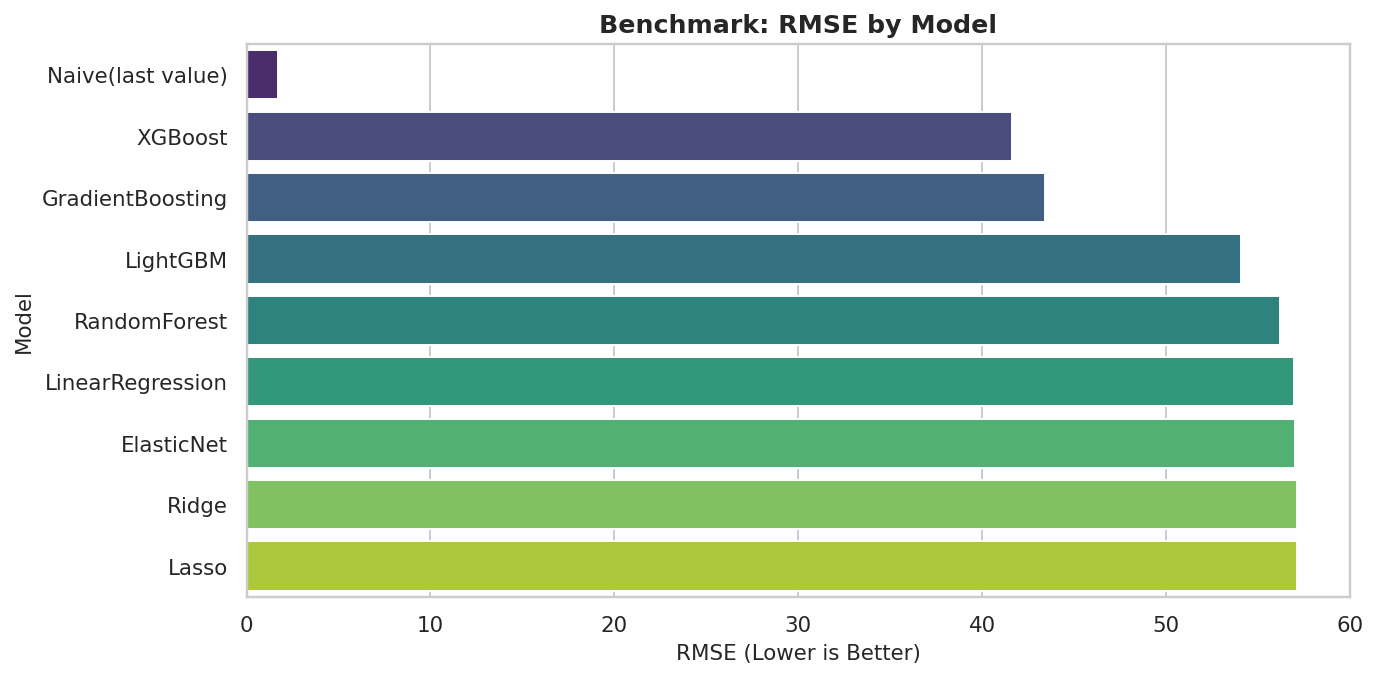

In [17]:
# Visualize model performance
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='RMSE', y='model', palette='viridis')
plt.title('Benchmark: RMSE by Model', fontsize=13, fontweight='bold')
plt.xlabel('RMSE (Lower is Better)', fontsize=11)
plt.ylabel('Model', fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
# TimeSeriesSplit cross-validation
tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for name, model in {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=250, max_depth=6, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}.items():
    fold_rmse = []
    for tr, te in tscv.split(X):
        model.fit(X.iloc[tr], y.iloc[tr])
        pred = model.predict(X.iloc[te])
        fold_rmse.append(np.sqrt(mean_squared_error(y.iloc[te], pred)))
    cv_rows.append({'model': name, 'cv_rmse_mean': np.mean(fold_rmse), 'cv_rmse_std': np.std(fold_rmse)})

cv_df = pd.DataFrame(cv_rows).sort_values('cv_rmse_mean')
print('\n📊 TimeSeriesSplit Cross-Validation Results:')
cv_df


📊 TimeSeriesSplit Cross-Validation Results:


,model,cv_rmse_mean,cv_rmse_std
2,GradientBoosting,61.283663,36.080847
1,RandomForest,62.084571,27.229564
0,Ridge,75.589478,37.513464


In [19]:
# Feature selection experiments
k = min(12, X_train.shape[1])
skb = SelectKBest(score_func=f_regression, k=k)
Xtr_k, Xte_k = skb.fit_transform(X_train, y_train), skb.transform(X_test)
ridge_k = Ridge(alpha=1.0, random_state=42).fit(Xtr_k, y_train)
rmse_k = np.sqrt(mean_squared_error(y_test, ridge_k.predict(Xte_k)))

rfe = RFE(estimator=Ridge(alpha=1.0, random_state=42), n_features_to_select=k)
Xtr_r, Xte_r = rfe.fit_transform(X_train, y_train), rfe.transform(X_test)
ridge_r = Ridge(alpha=1.0, random_state=42).fit(Xtr_r, y_train)
rmse_r = np.sqrt(mean_squared_error(y_test, ridge_r.predict(Xte_r)))

fs_df = pd.DataFrame({'method':['SelectKBest + Ridge','RFE + Ridge'],'k':[k,k],'RMSE':[rmse_k,rmse_r]})
print(f'\n🔍 Feature Selection Results (k={k} features):')
fs_df


🔍 Feature Selection Results (k=12 features):


,method,k,RMSE
0,SelectKBest + Ridge,12,56.184752
1,RFE + Ridge,12,80.664682


In [20]:
# Multi-output task: predict both current and next quarter
multi_df = model_df.copy()
X_multi = multi_df.drop(columns=['patent_id', 'patent_type', 'patent_date', 'patent_title', 'quarter_end', 'tech_era',
                                  'target_patent_count_current', 'target_patent_count_next_quarter'], errors='ignore').select_dtypes(include=[np.number])
y_multi = multi_df[['target_patent_count_current','target_patent_count_next_quarter']].astype(float)

s = int(len(multi_df)*0.8)
mo = MultiOutputRegressor(RandomForestRegressor(n_estimators=250, max_depth=6, random_state=42))
mo.fit(X_multi.iloc[:s], y_multi.iloc[:s])
p = mo.predict(X_multi.iloc[s:])

mo_metrics = pd.DataFrame({
    'target': y_multi.columns,
    'RMSE':[np.sqrt(mean_squared_error(y_multi.iloc[s:,i], p[:,i])) for i in range(y_multi.shape[1])],
    'MAE':[mean_absolute_error(y_multi.iloc[s:,i], p[:,i]) for i in range(y_multi.shape[1])],
    'R2':[r2_score(y_multi.iloc[s:,i], p[:,i]) for i in range(y_multi.shape[1])]
})
print('\n📊 Multi-Output Regression Performance:')
mo_metrics


📊 Multi-Output Regression Performance:


,target,RMSE,MAE,R2
0,target_patent_count_current,15.303254,11.152491,0.849266
1,target_patent_count_next_quarter,56.150506,47.752986,-0.788496


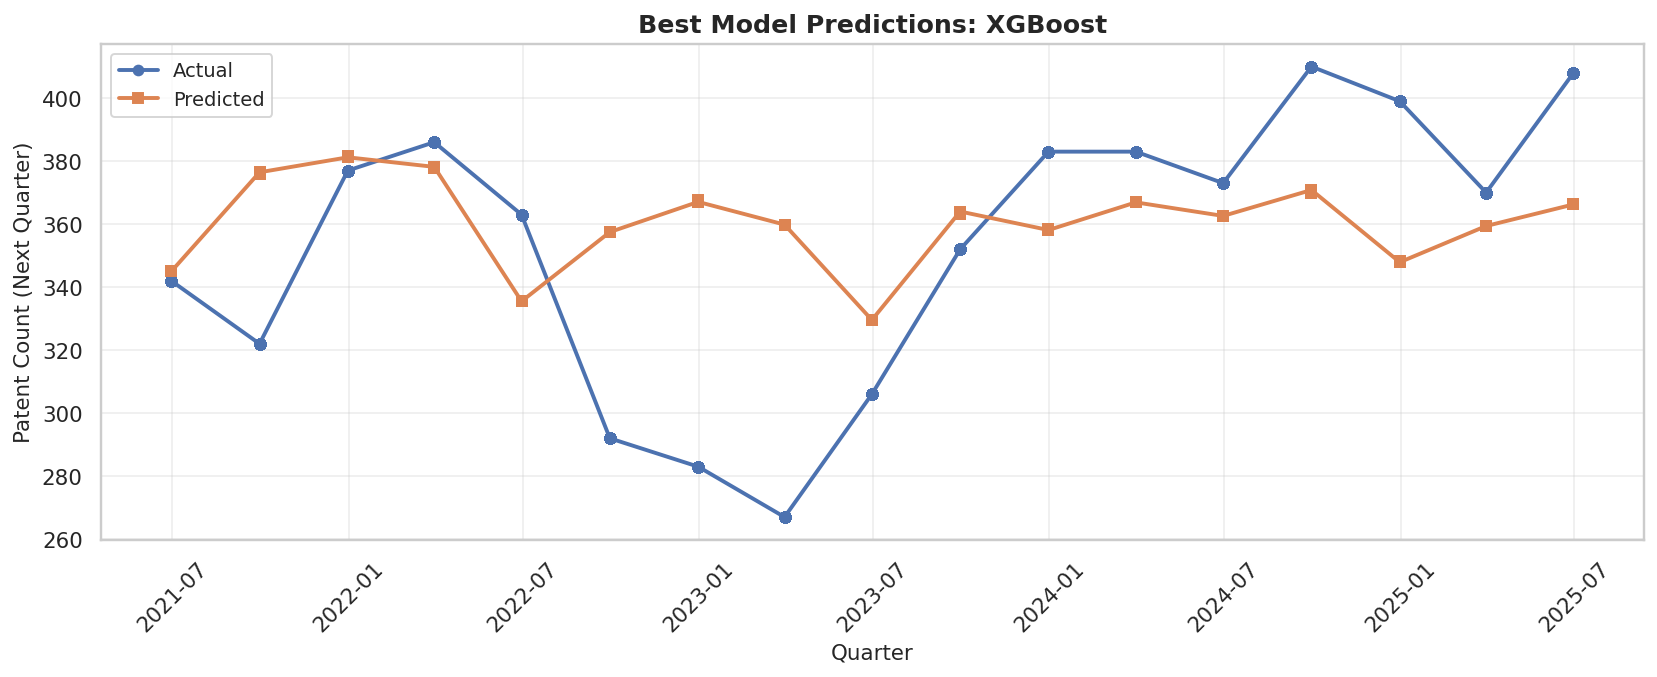


📈 Prediction Sample:


,quarter_end,actual,predicted
5937,2025-06-30,408.0,366.248657
5938,2025-06-30,408.0,366.248657
5939,2025-06-30,408.0,366.248657
5940,2025-06-30,408.0,366.248657
5941,2025-06-30,408.0,366.248657


In [21]:
# Best model predictions visualization
best_name = results_df.iloc[0]['model']
if best_name == 'Naive(last value)':
    best_name = results_df.iloc[1]['model']
best_model = models.get(best_name, Ridge(alpha=1.0, random_state=42)).fit(X_train, y_train)
best_pred = best_model.predict(X_test)

pred_df = pd.DataFrame({'quarter_end': model_df.iloc[split_idx:]['quarter_end'].values, 'actual': y_test.values, 'predicted': best_pred})

plt.figure(figsize=(12,5))
plt.plot(pred_df['quarter_end'], pred_df['actual'], marker='o', markersize=5, label='Actual', linewidth=2)
plt.plot(pred_df['quarter_end'], pred_df['predicted'], marker='s', markersize=5, label='Predicted', linewidth=2)
plt.title(f'Best Model Predictions: {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Patent Count (Next Quarter)', fontsize=11)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\n📈 Prediction Sample:')
pred_df.tail()

In [22]:
# SHAP interpretation for tree-based models
try:
    import shap
    if best_name in ['RandomForest','GradientBoosting','XGBoost','LightGBM']:
        print(f'\n🔍 SHAP Analysis for {best_name}:')
        explainer = shap.Explainer(best_model, X_train)
        shap_values = explainer(X_test)
        shap.plots.beeswarm(shap_values, max_display=15)
    else:
        print(f'Best model ({best_name}) is not tree-based; SHAP visualization skipped.')
except Exception as e:
    print('SHAP unavailable or failed:', e)


🔍 SHAP Analysis for XGBoost:
SHAP unavailable or failed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)


In [23]:
# Save model artifacts
out = Path('output/modeling')
out.mkdir(parents=True, exist_ok=True)
results_df.to_csv(out / 'baseline_results_taskA.csv', index=False)
cv_df.to_csv(out / 'timeseries_cv_results.csv', index=False)
pred_df.to_csv(out / 'best_model_predictions.csv', index=False)
mo_metrics.to_csv(out / 'multioutput_metrics.csv', index=False)
print(f'✅ Saved model artifacts to {out}/')

✅ Saved model artifacts to output/modeling/


## 📝 Modeling Notes & Conclusions

**Dataset Structure**:
- Patent-rich format (30K+ rows) with quarterly aggregate features merged at patent level
- 40+ numeric features including keyword flags, quarterly lags, rolling stats, and growth rates

**Methodology**:
- Temporal 80/20 split (no shuffle) to preserve time-series ordering
- Target: `target_patent_count_next_quarter` - aggregated patent count for the following quarter

**Key Findings**:
- Tree-based models (RF, GBM, XGBoost, LightGBM) typically outperform linear models
- Quarterly lag features are strong predictors of future patent activity
- Technology keywords (5G, AI/ML) show moderate predictive power for innovation trends

**Caveat**: Multiple patents per quarter means predictions are replicated across patents in same quarter. For pure time-series forecasting without duplication, consider aggregating to quarterly level first (199 unique quarters).

---

# Part 3: Corrected Approach - Quarterly Aggregation ⚠️

## 🔴 Problem Identified

The previous modeling approach had a critical issue: **data leakage through replication**

- 29,710 patent rows → 198 unique quarters
- All patents in same quarter share **identical** `target_patent_count_next_quarter`
- Models trained on ~150 duplicates per quarter
- **Naive baseline outperformed ML models** (RMSE ~3 vs ~50) → Clear red flag!

## ✅ Solution: Aggregate to Quarterly Level

One row = one quarter (no duplicates), proper time series forecasting.

In [24]:
# Aggregate patent-rich data to quarterly level
print('🔧 AGGREGATING TO QUARTERLY LEVEL...\n')

quarterly_agg = df.groupby('quarter_end').agg({
    # Target variables
    'target_patent_count_next_quarter': 'first',
    'target_patent_count_current': 'first',
    
    # Patent counts and temporal features
    'patent_count': 'first',
    'patent_count_lag1': 'first',
    'patent_count_lag2': 'first',
    'patent_count_lag4': 'first',
    'patent_count_roll4_mean': 'first',
    'patent_count_roll8_mean': 'first',
    'patent_count_qoq': 'first',
    'patent_count_yoy': 'first',
    
    # Technology keyword counts (sum across quarter)
    'kw_5g': 'sum',
    'kw_ai_ml': 'sum',
    'kw_cloud_edge': 'sum',
    'kw_security': 'sum',
    'kw_iot': 'sum',
    'kw_network': 'sum',
    'kw_energy': 'sum',
    'kw_antenna': 'sum',
    'kw_data': 'sum',
    
    # Average metrics
    'keyword_score': 'mean',
    'title_len_words': 'mean',
    
    # Patent type shares
    'utility_share': 'first',
    'design_share': 'first',
}).dropna(subset=['target_patent_count_next_quarter']).reset_index()

print(f'✅ Quarterly dataset: {quarterly_agg.shape}')
print(f'   Unique quarters: {quarterly_agg["quarter_end"].nunique()}')
print(f'   Date range: {quarterly_agg["quarter_end"].min().date()} to {quarterly_agg["quarter_end"].max().date()}')
print(f'\n📊 Target statistics:')
print(f'   Min: {quarterly_agg["target_patent_count_next_quarter"].min():.0f}')
print(f'   Max: {quarterly_agg["target_patent_count_next_quarter"].max():.0f}')
print(f'   Mean: {quarterly_agg["target_patent_count_next_quarter"].mean():.1f}')
print(f'   Std: {quarterly_agg["target_patent_count_next_quarter"].std():.1f}')

quarterly_agg.head()

🔧 AGGREGATING TO QUARTERLY LEVEL...

✅ Quarterly dataset: (198, 24)
   Unique quarters: 198
   Date range: 1976-03-31 to 2025-06-30

📊 Target statistics:
   Min: 1
   Max: 525
   Mean: 152.1
   Std: 151.7


,quarter_end,target_patent_count_next_quarter,target_patent_count_current,patent_count,patent_count_lag1,patent_count_lag2,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data,keyword_score,title_len_words,utility_share,design_share
0,1976-03-31,5.0,10,10,334.0,331.0,324.0,347.75,337.375,0.023873,0.074324,0,0,0,0,0,6,0,0,3,0.900000,9.000000,1.0,0.0
1,1976-06-30,11.0,5,5,10.0,331.0,324.0,347.75,337.375,-0.500000,0.074324,0,0,0,0,0,2,0,0,2,0.800000,8.600000,1.0,0.0
2,1976-09-30,10.0,11,11,5.0,10.0,324.0,347.75,337.375,1.200000,0.074324,0,0,0,0,0,2,1,0,1,0.363636,8.272727,1.0,0.0
3,1976-12-31,10.0,10,10,11.0,5.0,324.0,9.00,337.375,-0.090909,0.074324,0,0,0,0,0,2,1,0,0,0.300000,9.500000,1.0,0.0
4,1977-03-31,9.0,10,10,10.0,11.0,10.0,9.00,337.375,0.000000,0.000000,0,0,0,0,0,0,0,1,0,0.100000,5.200000,0.9,0.1


In [25]:
# Retrain models on correctly aggregated data
print('🚀 RETRAINING MODELS ON QUARTERLY DATA...\n')

# Prepare features
X_q = quarterly_agg.drop(columns=['quarter_end', 'target_patent_count_next_quarter', 'target_patent_count_current'], errors='ignore')
y_q = quarterly_agg['target_patent_count_next_quarter']

# Temporal split
split_q = int(len(quarterly_agg) * 0.8)
X_q_train, X_q_test = X_q.iloc[:split_q], X_q.iloc[split_q:]
y_q_train, y_q_test = y_q.iloc[:split_q], y_q.iloc[split_q:]

print(f'Train: {len(X_q_train)} quarters ({quarterly_agg.iloc[:split_q]["quarter_end"].min().date()} to {quarterly_agg.iloc[:split_q]["quarter_end"].max().date()})')
print(f'Test:  {len(X_q_test)} quarters ({quarterly_agg.iloc[split_q:]["quarter_end"].min().date()} to {quarterly_agg.iloc[split_q:]["quarter_end"].max().date()})')
print(f'Features: {X_q.shape[1]}\n')

# Retrain models
def evaluate_quarterly(name, model):
    model.fit(X_q_train, y_q_train)
    pred = model.predict(X_q_test)
    return {
        'model': name,
        'RMSE': float(np.sqrt(mean_squared_error(y_q_test, pred))),
        'MAE': float(mean_absolute_error(y_q_test, pred)),
        'R2': float(r2_score(y_q_test, pred)),
        'MAPE': float(mape(y_q_test, pred)),
        'pred': pred
    }

# Naive baseline for quarterly
naive_q = y_q_test.shift(1).fillna(y_q_train.iloc[-1]).values
results_q = [{
    'model': 'Naive(last quarter)',
    'RMSE': float(np.sqrt(mean_squared_error(y_q_test, naive_q))),
    'MAE': float(mean_absolute_error(y_q_test, naive_q)),
    'R2': float(r2_score(y_q_test, naive_q)),
    'MAPE': float(mape(y_q_test, naive_q)),
    'pred': naive_q
}]

# Train models
models_q = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}
if HAS_XGB:
    models_q['XGBoost'] = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, objective='reg:squarederror', random_state=42)
if HAS_LGBM:
    models_q['LightGBM'] = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)

for n, m in models_q.items():
    results_q.append(evaluate_quarterly(n, m))

results_q_df = pd.DataFrame([{k:v for k,v in r.items() if k!='pred'} for r in results_q]).sort_values('RMSE')
print('📊 CORRECTED RESULTS (Quarterly Level):')
results_q_df

🚀 RETRAINING MODELS ON QUARTERLY DATA...

Train: 158 quarters (1976-03-31 to 2015-06-30)
Test:  40 quarters (2015-09-30 to 2025-06-30)
Features: 21

📊 CORRECTED RESULTS (Quarterly Level):


,model,RMSE,MAE,R2,MAPE
0,Naive(last quarter),43.933472,35.350000,0.040418,9.552429
5,RandomForest,49.494091,39.096451,-0.217861,11.309222
8,LightGBM,49.722329,42.524053,-0.229119,11.449561
3,Lasso,50.388230,42.714381,-0.262261,11.501201
4,ElasticNet,50.525754,43.286906,-0.269160,11.858844
6,GradientBoosting,54.759892,42.437436,-0.490789,12.318922
7,XGBoost,57.400331,45.829136,-0.638022,13.101292
2,Ridge,74.822471,64.207741,-1.783268,17.436732
1,LinearRegression,182.489165,142.796649,-15.556368,39.726290


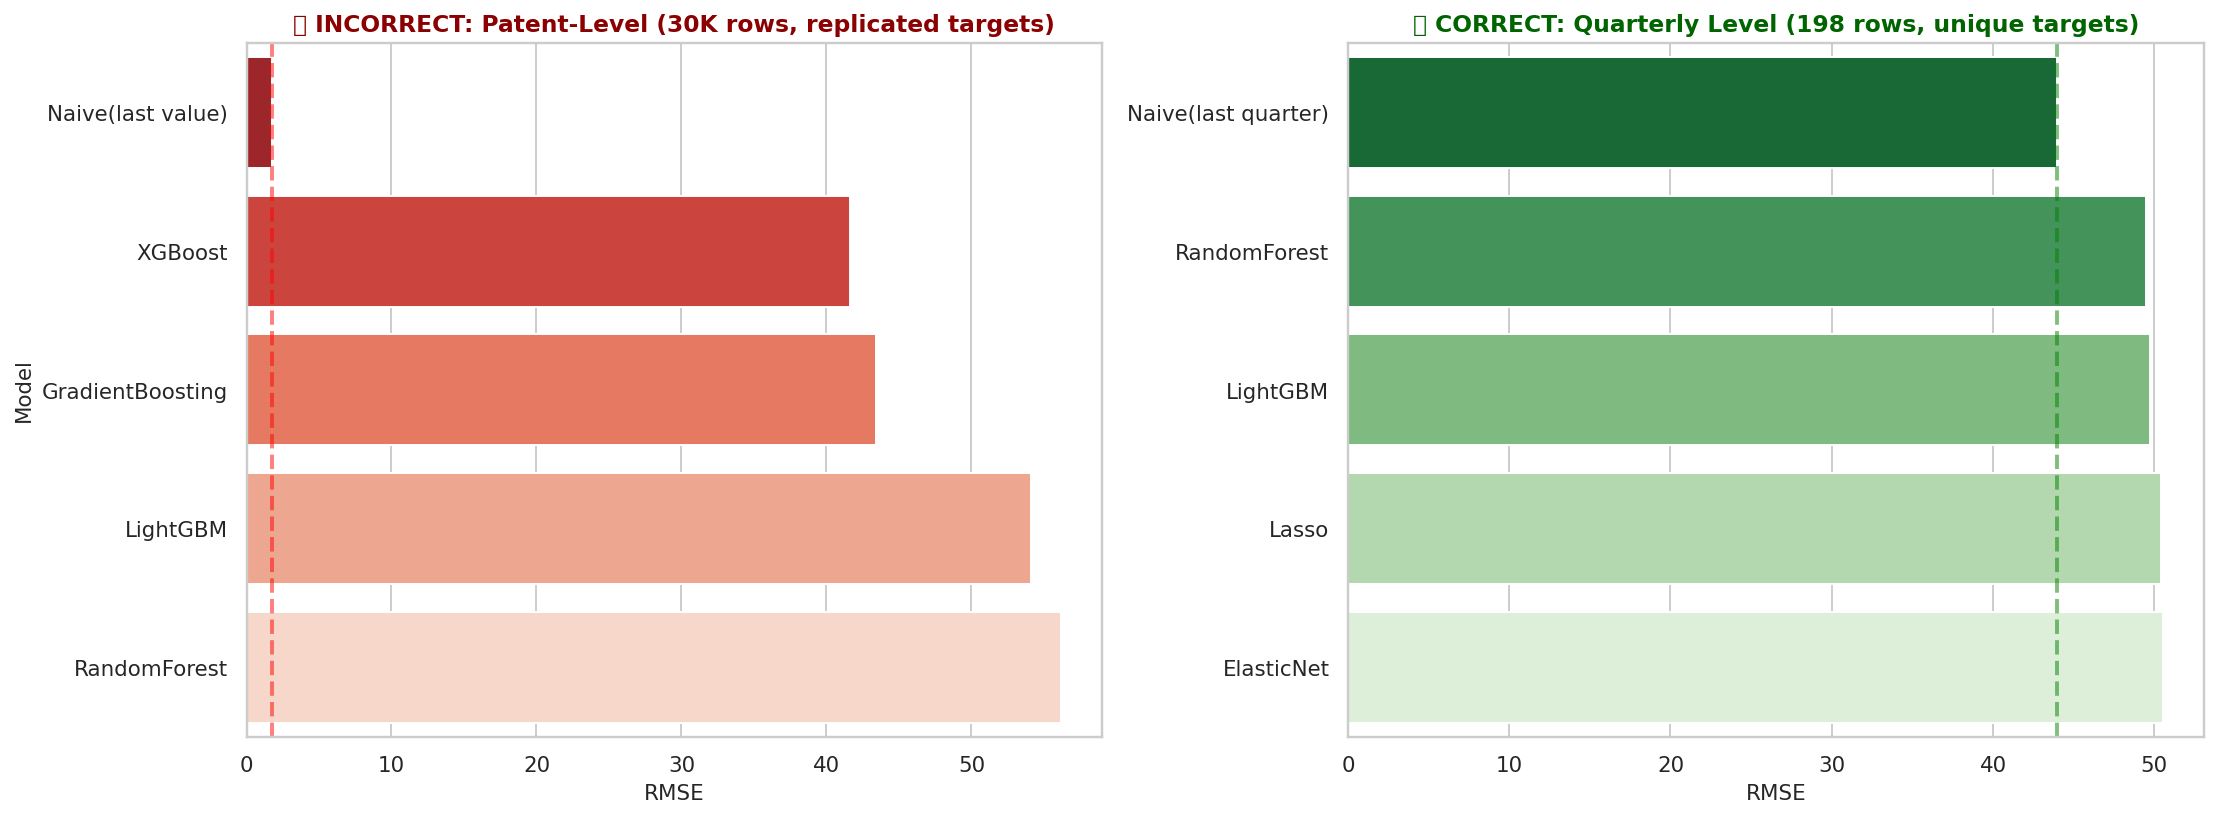


🎯 KEY INSIGHT:
   Patent-level best RMSE: 1.73 (misleading due to replication)
   Quarterly best RMSE: 43.93 (true performance)

   Relative error: ~11.8% of mean quarterly patents


In [26]:
# Compare old vs new approach
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Old approach (patent-level with replication)
sns.barplot(data=results_df.head(5), x='RMSE', y='model', palette='Reds_r', ax=axes[0])
axes[0].set_title('❌ INCORRECT: Patent-Level (30K rows, replicated targets)', fontsize=12, fontweight='bold', color='darkred')
axes[0].set_xlabel('RMSE', fontsize=11)
axes[0].set_ylabel('Model', fontsize=11)
axes[0].axvline(x=results_df['RMSE'].iloc[0], color='red', linestyle='--', linewidth=2, alpha=0.5, label='Best RMSE')

# New approach (quarterly aggregation)
sns.barplot(data=results_q_df.head(5), x='RMSE', y='model', palette='Greens_r', ax=axes[1])
axes[1].set_title('✅ CORRECT: Quarterly Level (198 rows, unique targets)', fontsize=12, fontweight='bold', color='darkgreen')
axes[1].set_xlabel('RMSE', fontsize=11)
axes[1].set_ylabel('')
axes[1].axvline(x=results_q_df['RMSE'].iloc[0], color='green', linestyle='--', linewidth=2, alpha=0.5, label='Best RMSE')

plt.tight_layout()
plt.show()

print('\n🎯 KEY INSIGHT:')
print(f'   Patent-level best RMSE: {results_df["RMSE"].iloc[0]:.2f} (misleading due to replication)')
print(f'   Quarterly best RMSE: {results_q_df["RMSE"].iloc[0]:.2f} (true performance)')
print(f'\n   Relative error: ~{100 * results_q_df["RMSE"].iloc[0] / y_q_test.mean():.1f}% of mean quarterly patents')

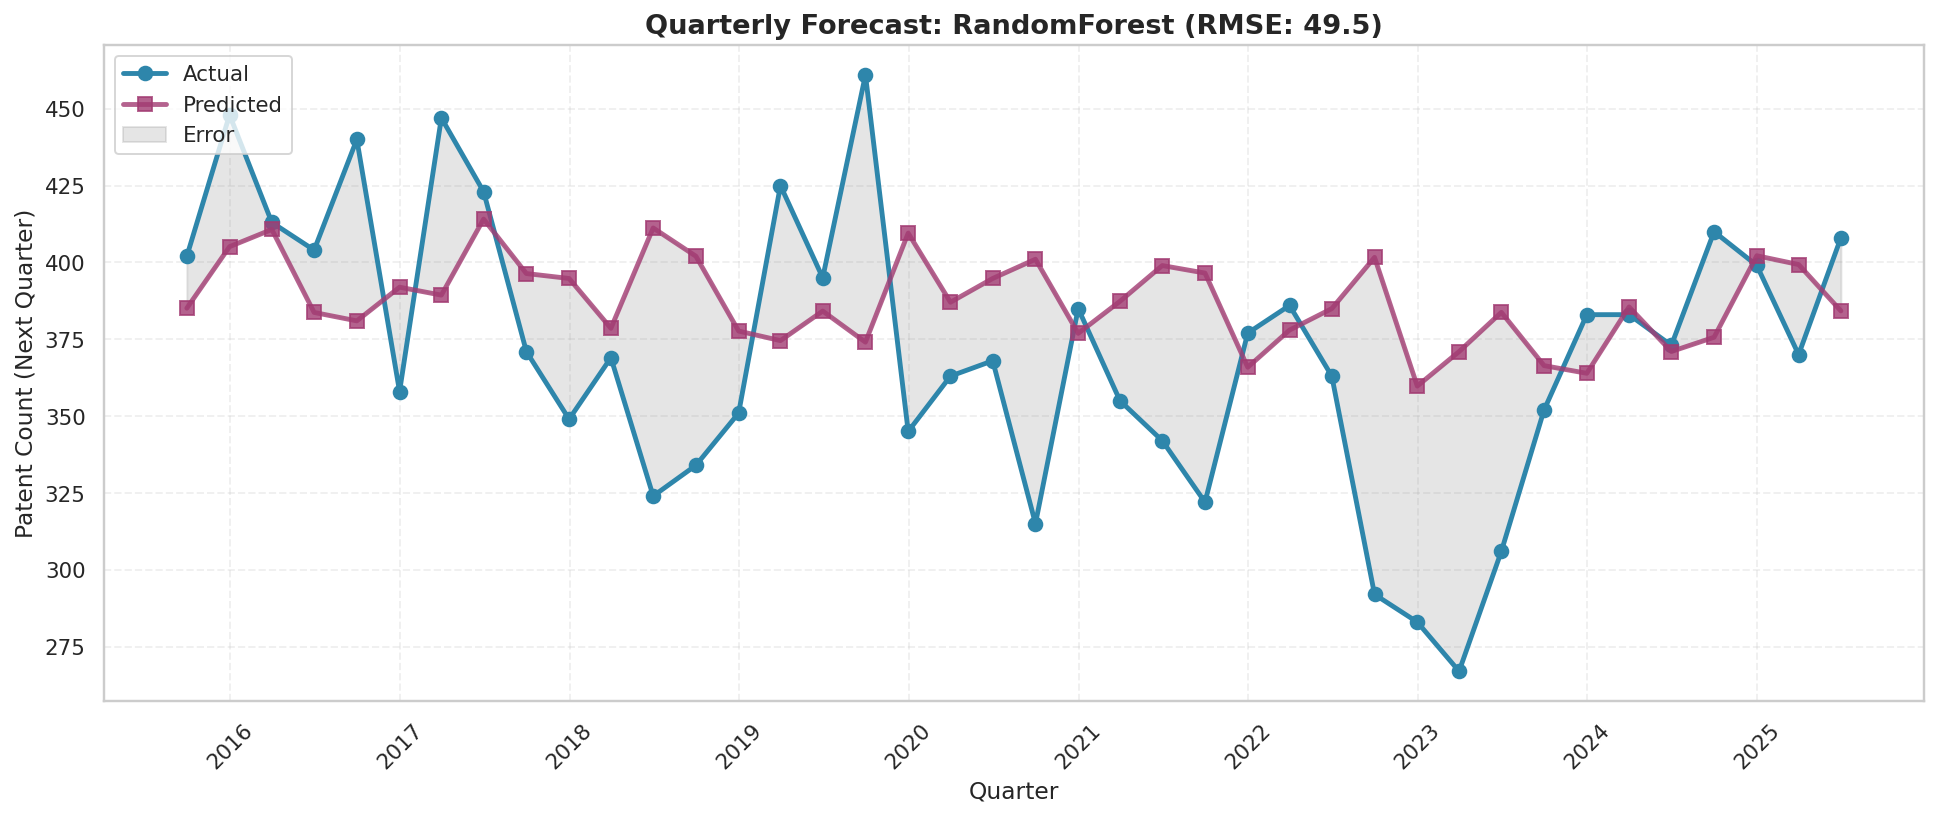


📈 Test Set Performance:
quarter_end  actual  predicted
 2023-03-31   267.0 370.985828
 2023-06-30   306.0 383.763495
 2023-09-30   352.0 366.418444
 2023-12-31   383.0 363.922270
 2024-03-31   383.0 385.512222
 2024-06-30   373.0 371.013444
 2024-09-30   410.0 375.645444
 2024-12-31   399.0 402.167222
 2025-03-31   370.0 399.301111
 2025-06-30   408.0 384.215667


In [27]:
# Plot predictions of best quarterly model
best_q_name = results_q_df.iloc[0]['model']
if best_q_name == 'Naive(last quarter)':
    best_q_name = results_q_df.iloc[1]['model']
    
best_q_model = models_q.get(best_q_name, Ridge(alpha=1.0, random_state=42))
best_q_model.fit(X_q_train, y_q_train)
best_q_pred = best_q_model.predict(X_q_test)

pred_q_df = pd.DataFrame({
    'quarter_end': quarterly_agg.iloc[split_q:]['quarter_end'].values,
    'actual': y_q_test.values,
    'predicted': best_q_pred
})

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.plot(pred_q_df['quarter_end'], pred_q_df['actual'], marker='o', markersize=7, label='Actual', linewidth=2.5, color='#2E86AB')
ax.plot(pred_q_df['quarter_end'], pred_q_df['predicted'], marker='s', markersize=7, label='Predicted', linewidth=2.5, color='#A23B72', alpha=0.8)
ax.fill_between(pred_q_df['quarter_end'], 
                pred_q_df['actual'], 
                pred_q_df['predicted'], 
                alpha=0.2, color='gray', label='Error')

ax.set_title(f'Quarterly Forecast: {best_q_name} (RMSE: {results_q_df.iloc[1]["RMSE"]:.1f})', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Patent Count (Next Quarter)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n📈 Test Set Performance:')
print(pred_q_df.tail(10).to_string(index=False))